In [1]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from PIL import Image
from pathlib import Path

In [2]:
class ChessBoard:
    def __init__(self, marked_squares=None):
        """
        marked_squares:
        [
            (columna, fila, valor),
            ...
        ]
        """
        self.marked_squares = marked_squares or []
        self.files = "abcdefgh"

    def _validate_square(self, square):
        if not isinstance(square, tuple) or len(square) != 3:
            raise ValueError(
                f"Formato inválido: {square}. "
                "Debe ser (columna, fila, valor)"
            )

        col, row, _ = square

        if not isinstance(col, int) or not isinstance(row, int):
            raise ValueError(f"Columna y fila deben ser enteros: {square}")

        if not (1 <= col <= 8 and 1 <= row <= 8):
            raise ValueError(f"Casilla fuera del tablero: {square}")

    def draw(self, save_path=None):
        fig, ax = plt.subplots(figsize=(8, 8))

        # Dibujar tablero
        for row in range(8):
            for col in range(8):
                color = "white" if (row + col) % 2 == 0 else "gray"

                ax.add_patch(
                    Rectangle(
                        (col, row),
                        1,
                        1,
                        facecolor=color,
                        edgecolor="black"
                    )
                )

        # Marcar casillas y escribir valor
        for square in self.marked_squares:
            self._validate_square(square)

            col, row, value = square

            x = col - 1
            y = row - 1

            # Marca
            ax.add_patch(
                Rectangle(
                    (x, y),
                    1,
                    1,
                    facecolor="red",
                    alpha=0.6
                )
            )

            # Valor
            ax.text(
                x + 0.5,
                y + 0.5,
                str(value),
                ha="center",
                va="center",
                fontsize=14,
                fontweight="bold",
                color="white"
            )

        # Numeración
        ax.set_xticks([i + 0.5 for i in range(8)])
        ax.set_xticklabels(self.files)

        ax.set_yticks([i + 0.5 for i in range(8)])
        ax.set_yticklabels(range(1, 9))

        ax.set_xlim(0, 8)
        ax.set_ylim(0, 8)
        ax.set_aspect("equal")

        if save_path:
            plt.savefig(save_path, bbox_inches="tight")

        plt.close()


In [3]:
def posibles_vecinos(x,y):
    return [(x+1,y+2),(x+1,y-2),(x-1,y+2),(x-1,y-2),(x+2,y+1),(x+2,y-1),(x-2,y+1), (x-2,y-1) ]
def vecinos_validos(x,y):
    return [(i,j) for (i,j) in posibles_vecinos(x,y) if i>=1 and i<=8 and j>=1 and j<=8]

In [4]:
def marcar_movimientos(lista: list[tuple], lista_marca: list[tuple], marca: str):
    new = []
    for x, y in lista:
        vecinos = vecinos_validos(x, y)
        for v in vecinos:
            if v not in lista+new:
                new.append(v)
    new_marca = [(i, j, marca) for i, j in new]
    lista += new
    lista_marca += new_marca
    return lista, lista_marca


In [5]:
def crear_tablero(x, y):
    path = f"./images/{x}_{y}"
    Path(path).mkdir(exist_ok=True)
    
    marca = 0
    lista = [(x, y)]
    lista_marca = [(x, y, str(marca))]
    board = ChessBoard(lista_marca)
    board.draw(f"{path}/tablero_{marca}.png")

    marca = 1
    m, n = 0 , -1
    while n != m:
        n = len(lista)
        lista, lista_marca = marcar_movimientos(lista, lista_marca, str(marca))
        m = len(lista)
        if n != m:
            board = ChessBoard(lista_marca)
            board.draw(f"{path}/tablero_{marca}.png")
            marca += 1


In [6]:
from PIL import Image
from pathlib import Path
from IPython.display import display, Image as IPImage


class GifGenerator:
    def __init__(self, folder_path: str):
        self.folder = Path(folder_path)

    def generate(
        self,
        output_path="tablero.gif",
        duration=2000,
        loop=0
    ):
        image_paths = sorted(
            list(self.folder.glob("*.png")) +
            list(self.folder.glob("*.jpg")) +
            list(self.folder.glob("*.jpeg"))
        )

        if not image_paths:
            raise ValueError("No se encontraron imágenes en la carpeta.")

        images = [
            Image.open(path).convert("RGB")
            for path in image_paths
        ]

        images[0].save(
            output_path,
            save_all=True,
            append_images=images[1:],
            duration=duration,
            loop=loop
        )

        # Mostrar GIF en el notebook
        display(IPImage(filename=output_path))

In [10]:
x, y = 1, 1
# x, y = 4, 5
crear_tablero(x, y)

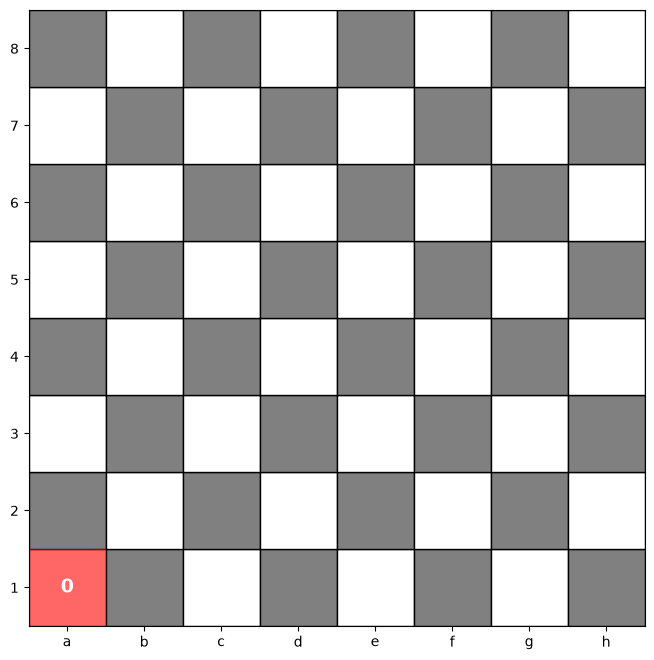

In [11]:
path = f"./images/{x}_{y}"
generator = GifGenerator(path)

generator.generate(
    output_path=f"./gif/evolucion_tablero_{x}_{y}.gif",
    duration=1500
)